In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ZBike_Rentals_Data.csv")
df["date"] = pd.to_datetime(df["date"])
print(df.head())

        date  temperature_C  humidity_pct  wind_speed_kmh  season weather  \
0 2023-01-01           24.5          82.6            24.2  summer   clear   
1 2023-01-02           21.3          74.4            12.5  spring   rainy   
2 2023-01-03           25.2          71.8            10.7  summer   rainy   
3 2023-01-04           29.6          72.1            22.4  summer  stormy   
4 2023-01-05           20.8          51.6             9.5    fall   clear   

    events    weekday  air_pressure_hpa     moon_phase  stock_index  \
0     none     Sunday            1016.7           full      15183.7   
1     none     Monday            1016.7   last_quarter       4685.9   
2  concert    Tuesday            1016.7           full       4802.1   
3     none  Wednesday            1016.7           full       5188.2   
4   sports   Thursday            1016.7  first_quarter       4803.5   

   tv_ad_spend  fuel_price  rental_count  
0       1153.7       92.57        1111.0  
1       4607.0       87.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              200 non-null    datetime64[ns]
 1   temperature_C     200 non-null    float64       
 2   humidity_pct      200 non-null    float64       
 3   wind_speed_kmh    200 non-null    float64       
 4   season            200 non-null    object        
 5   weather           162 non-null    object        
 6   events            200 non-null    object        
 7   weekday           197 non-null    object        
 8   air_pressure_hpa  200 non-null    float64       
 9   moon_phase        200 non-null    object        
 10  stock_index       200 non-null    float64       
 11  tv_ad_spend       200 non-null    float64       
 12  fuel_price        200 non-null    float64       
 13  rental_count      195 non-null    float64       
dtypes: datetime64[ns](1), floa

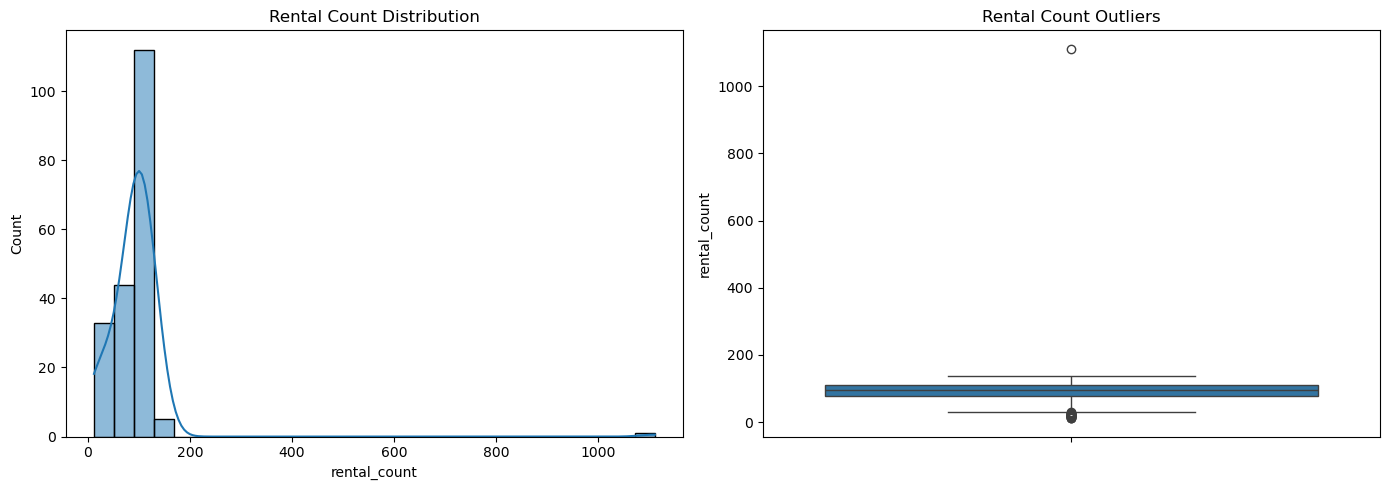

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(
    df["rental_count"],
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Rental Count Distribution")

# Boxplot
sns.boxplot(
    y=df["rental_count"],
    ax=axes[1]
)
axes[1].set_title("Rental Count Outliers")

plt.tight_layout()
plt.show()

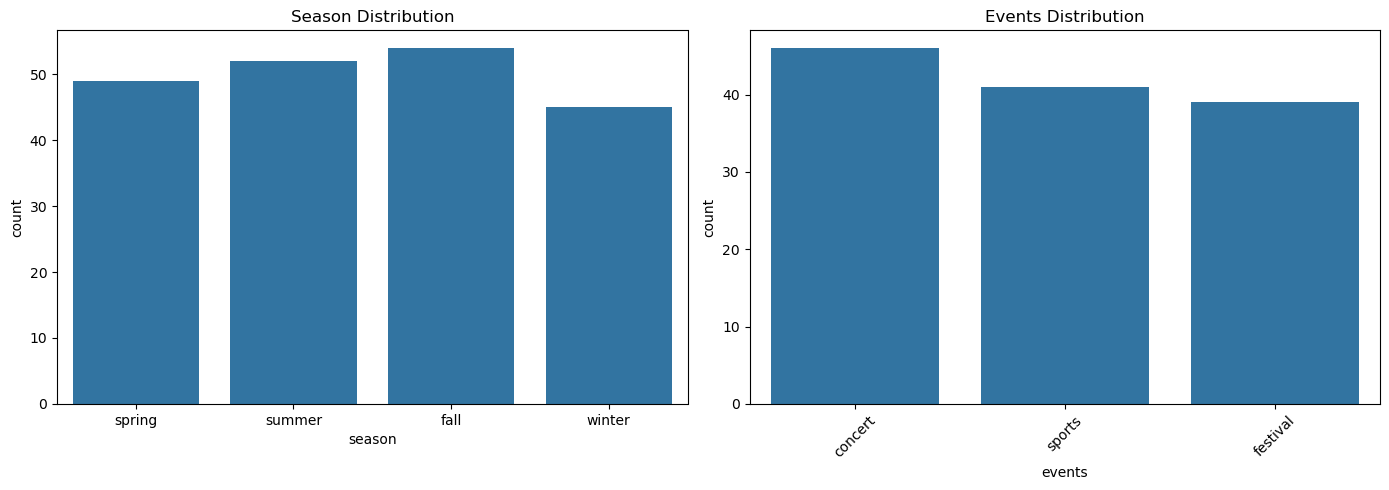

In [17]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
season_order = ["spring", "summer", "fall", "winter"]

sns.countplot(
    data=df,
    x="season",
    order=season_order,
    ax= axes[0]
)
axes[0].set_title("Season Distribution")

event_df = df[df["events"] != "none"]

sns.countplot(
    data=event_df,
    x="events",
    ax=axes[1]
)
axes[1].set_title("Events Distribution")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

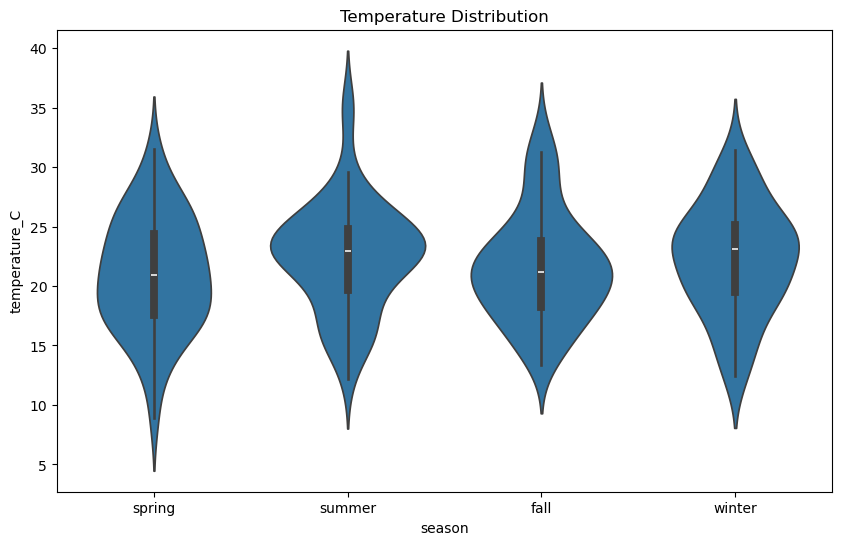

In [18]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="season",
    y="temperature_C",
    order=["spring", "summer", "fall", "winter"]
)

plt.title("Temperature Distribution")
plt.show()

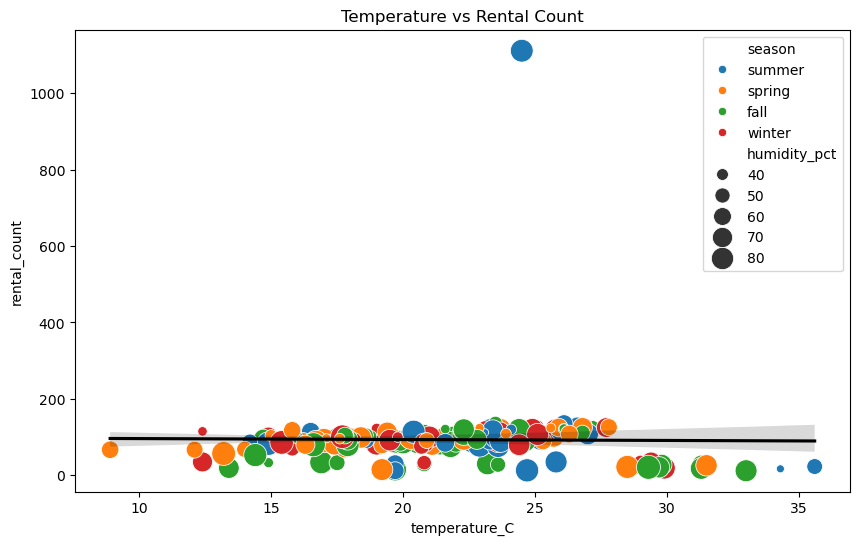

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="temperature_C",
    y="rental_count",
    hue="season",
    size="humidity_pct",
    sizes=(30,300)
)

sns.regplot(
    data=df,
    x="temperature_C",
    y="rental_count",
    scatter=False,
    color="black"
)

plt.title("Temperature vs Rental Count")
plt.show()

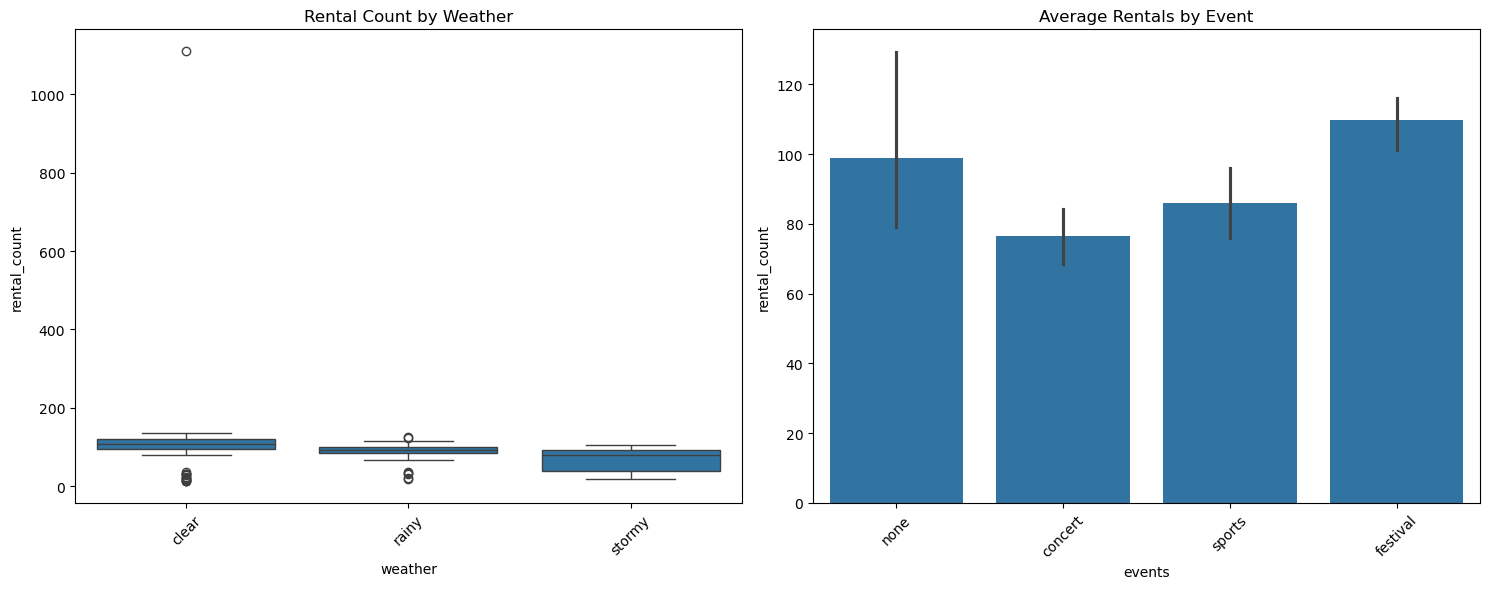

In [22]:
fig, axes = plt.subplots(1,2, figsize=(15,6))

#weather vs rental
sns.boxplot(
    data=df,
    x="weather",
    y="rental_count",
    ax=axes[0]
)

axes[0].set_title("Rental Count by Weather")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=df,
    x="events",
    y="rental_count",
    errorbar=("ci",95),
    ax=axes[1]
)

axes[1].set_title("Average Rentals by Event")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

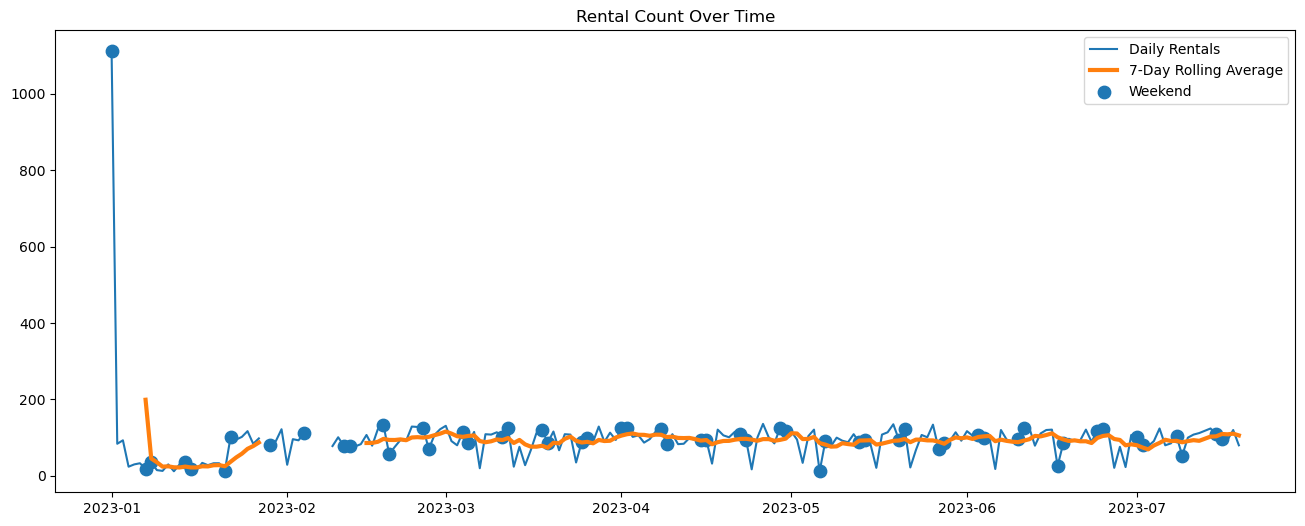

In [23]:
df = df.sort_values("date")

df["rolling_avg"] = (
    df["rental_count"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(16,6))

plt.plot(
    df["date"],
    df["rental_count"],
    label="Daily Rentals"
)

plt.plot(
    df["date"],
    df["rolling_avg"],
    linewidth=3,
    label="7-Day Rolling Average"
)

# Weekend highlighting
weekend_mask = df["weekday"].isin(
    ["Saturday", "Sunday"]
)

plt.scatter(
    df.loc[weekend_mask, "date"],
    df.loc[weekend_mask, "rental_count"],
    marker="o",
    s=80,
    label="Weekend"
)

plt.title("Rental Count Over Time")
plt.legend()
plt.show()

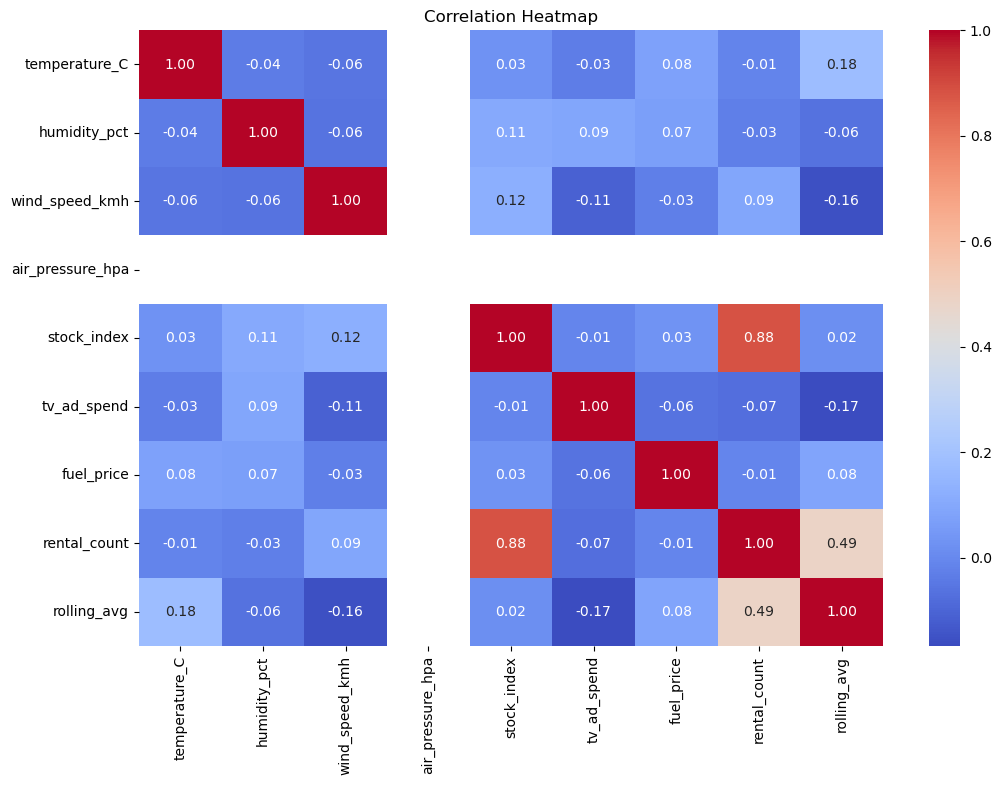

In [24]:
numeric_df = df.select_dtypes(
    include=np.number
)

corr = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [25]:
corr["rental_count"].sort_values(
    ascending=False
)

rental_count        1.000000
stock_index         0.881887
rolling_avg         0.487938
wind_speed_kmh      0.088045
fuel_price         -0.009414
temperature_C      -0.014045
humidity_pct       -0.029291
tv_ad_spend        -0.074275
air_pressure_hpa         NaN
Name: rental_count, dtype: float64

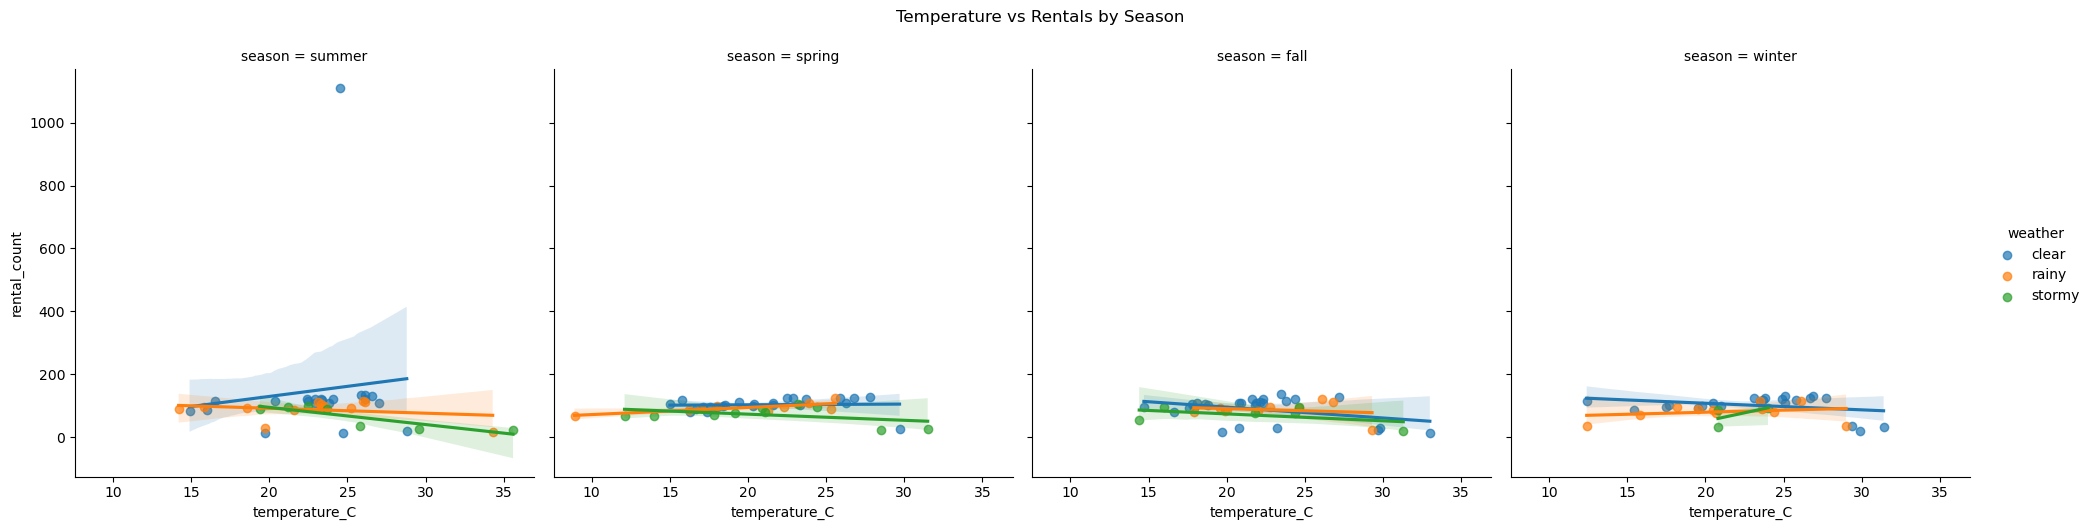

In [27]:
g = sns.lmplot(
    data=df,
    x="temperature_C",
    y="rental_count",
    col="season",
    hue="weather",
    height=5,
    aspect=1,
    markers="o",
    scatter_kws={"alpha":0.7}
)

g.fig.suptitle(
    "Temperature vs Rentals by Season",
    y=1.05
)

plt.show()